# Milestone 2: EDA & Feature Engineering
## Week 3 & 4 - Netflix Data Analysis

### Objectives:
1. Analyze Netflix content growth over time
2. Visualize distribution of genres, ratings, and content type
3. Identify country-level content contributions
4. Create derived features (Content Length Category, Original vs. Licensed)

In [37]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [38]:
# Load the cleaned dataset
df = pd.read_csv('netflix_titles_cleaned.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset Shape: (8807, 15)

Column Names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'genre_list', 'country_list', 'primary_country']

First few rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",['Documentaries'],['United States'],United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...","['International TV Shows', 'TV Dramas', 'TV My...",['South Africa'],South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,"['Crime TV Shows', 'International TV Shows', '...",['Unknown'],Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...","['Docuseries', 'Reality TV']",['Unknown'],Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,"['International TV Shows', 'Romantic TV Shows'...",['India'],India


In [39]:
# Check data types and info
print("Dataset Information:")
df.info()
print("\n" + "="*80)
print("\nBasic Statistics:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   show_id          8807 non-null   str  
 1   type             8807 non-null   str  
 2   title            8807 non-null   str  
 3   director         8807 non-null   str  
 4   cast             8807 non-null   str  
 5   country          8807 non-null   str  
 6   date_added       8807 non-null   str  
 7   release_year     8807 non-null   int64
 8   rating           8807 non-null   str  
 9   duration         8807 non-null   str  
 10  listed_in        8807 non-null   str  
 11  description      8807 non-null   str  
 12  genre_list       8807 non-null   str  
 13  country_list     8807 non-null   str  
 14  primary_country  8805 non-null   str  
dtypes: int64(1), str(14)
memory usage: 1.0 MB


Basic Statistics:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 1. Content Growth Over Time Analysis

In [40]:
# Parse date_added column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Check the parsed dates
print("Date Range:")
print(f"Earliest date added: {df['date_added'].min()}")
print(f"Latest date added: {df['date_added'].max()}")
print(f"\nRelease Year Range:")
print(f"Earliest release year: {df['release_year'].min()}")
print(f"Latest release year: {df['release_year'].max()}")

Date Range:
Earliest date added: 2008-01-01 00:00:00
Latest date added: 2021-09-25 00:00:00

Release Year Range:
Earliest release year: 1925
Latest release year: 2021


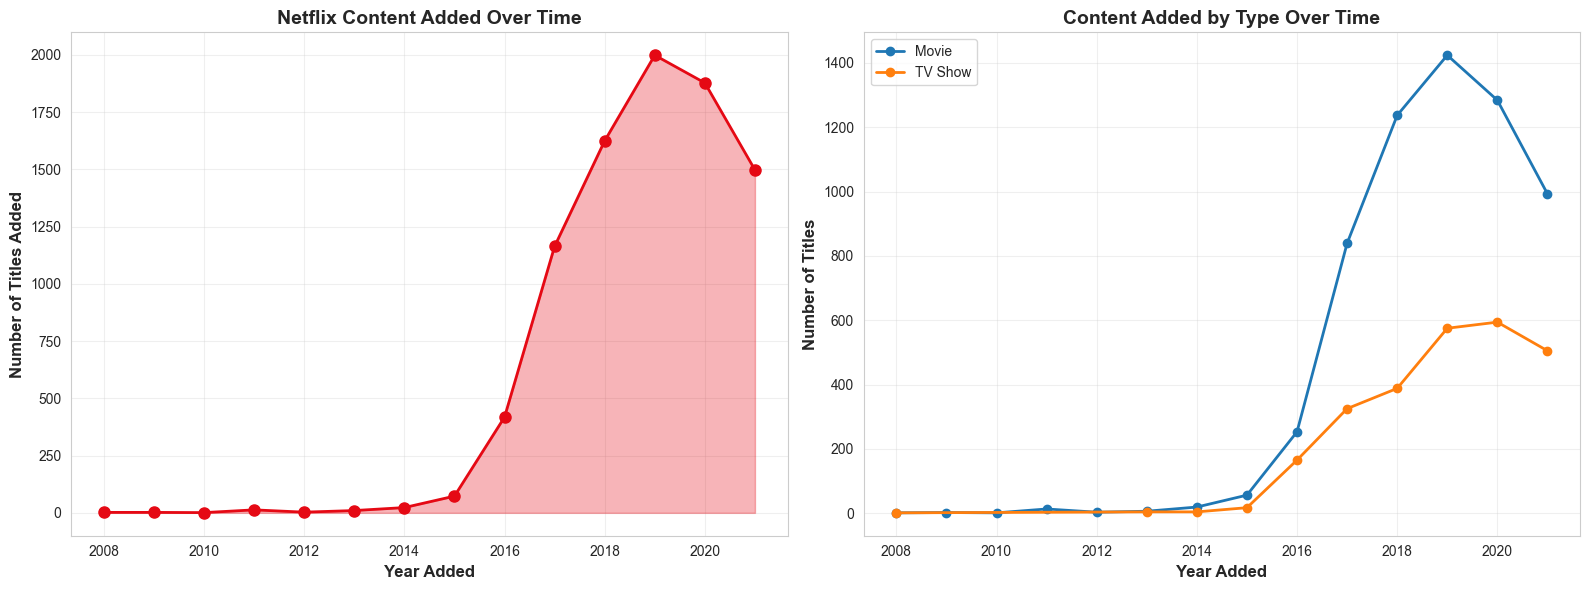


Total content by year added:
 year_added  count
     2008.0      2
     2009.0      2
     2010.0      1
     2011.0     13
     2012.0      3
     2013.0     10
     2014.0     23
     2015.0     73
     2016.0    418
     2017.0   1164
     2018.0   1625
     2019.0   1999
     2020.0   1878
     2021.0   1498


In [41]:
# Content added to Netflix per year
content_by_year_added = df.groupby('year_added').size().reset_index(name='count')
content_by_year_added = content_by_year_added.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total content added per year
ax1.plot(content_by_year_added['year_added'], content_by_year_added['count'], 
         marker='o', linewidth=2, markersize=8, color='#E50914')
ax1.set_xlabel('Year Added', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Titles Added', fontsize=12, fontweight='bold')
ax1.set_title('Netflix Content Added Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.fill_between(content_by_year_added['year_added'], 
                  content_by_year_added['count'], alpha=0.3, color='#E50914')

# Plot 2: Content by type and year added
content_by_type_year = df.groupby(['year_added', 'type']).size().reset_index(name='count')
content_by_type_year = content_by_type_year.dropna()

for content_type in content_by_type_year['type'].unique():
    data = content_by_type_year[content_by_type_year['type'] == content_type]
    ax2.plot(data['year_added'], data['count'], 
             marker='o', linewidth=2, markersize=6, label=content_type)

ax2.set_xlabel('Year Added', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Titles', fontsize=12, fontweight='bold')
ax2.set_title('Content Added by Type Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal content by year added:")
print(content_by_year_added.to_string(index=False))

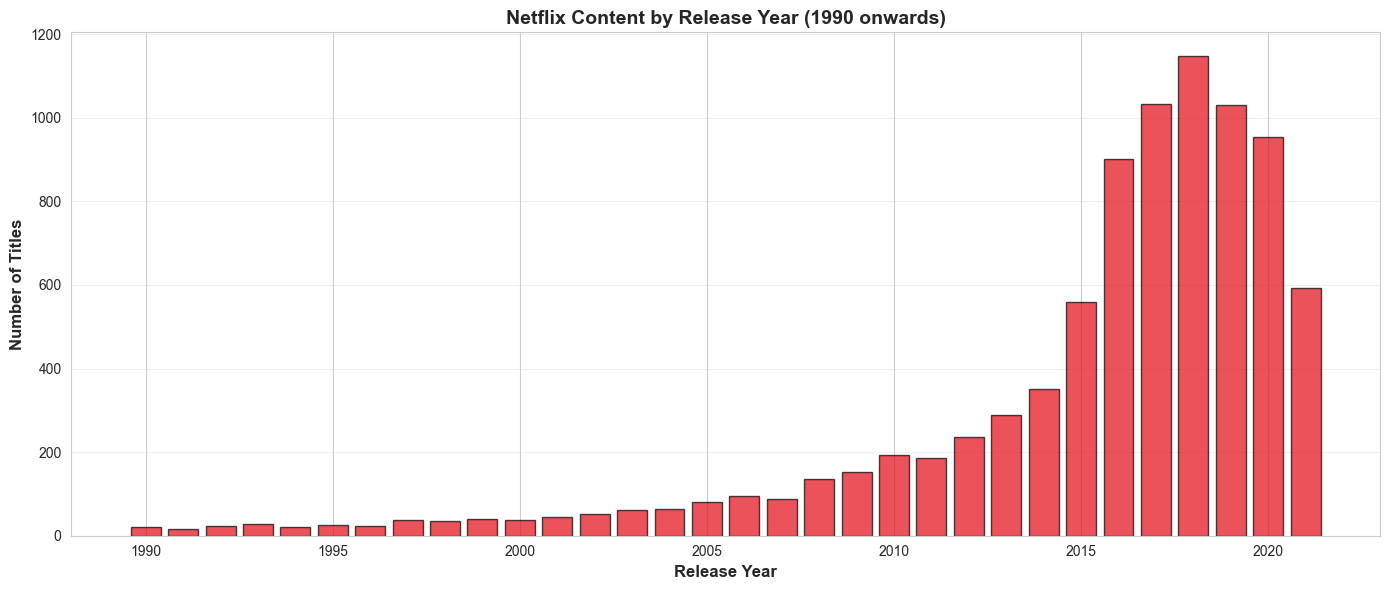


Top 10 years with most content releases:
 release_year  count
         2018   1147
         2017   1032
         2019   1030
         2020    953
         2016    902
         2021    592
         2015    560
         2014    352
         2013    288
         2012    237


In [42]:
# Analyze content by release year
content_by_release_year = df.groupby('release_year').size().reset_index(name='count')

# Focus on recent decades (filter data from 1990 onwards)
recent_content = content_by_release_year[content_by_release_year['release_year'] >= 1990]

plt.figure(figsize=(14, 6))
plt.bar(recent_content['release_year'], recent_content['count'], 
        color='#E50914', alpha=0.7, edgecolor='black')
plt.xlabel('Release Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Titles', fontsize=12, fontweight='bold')
plt.title('Netflix Content by Release Year (1990 onwards)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTop 10 years with most content releases:")
print(content_by_release_year.nlargest(10, 'count').to_string(index=False))

## 2. Distribution Analysis: Content Type, Ratings, and Genres

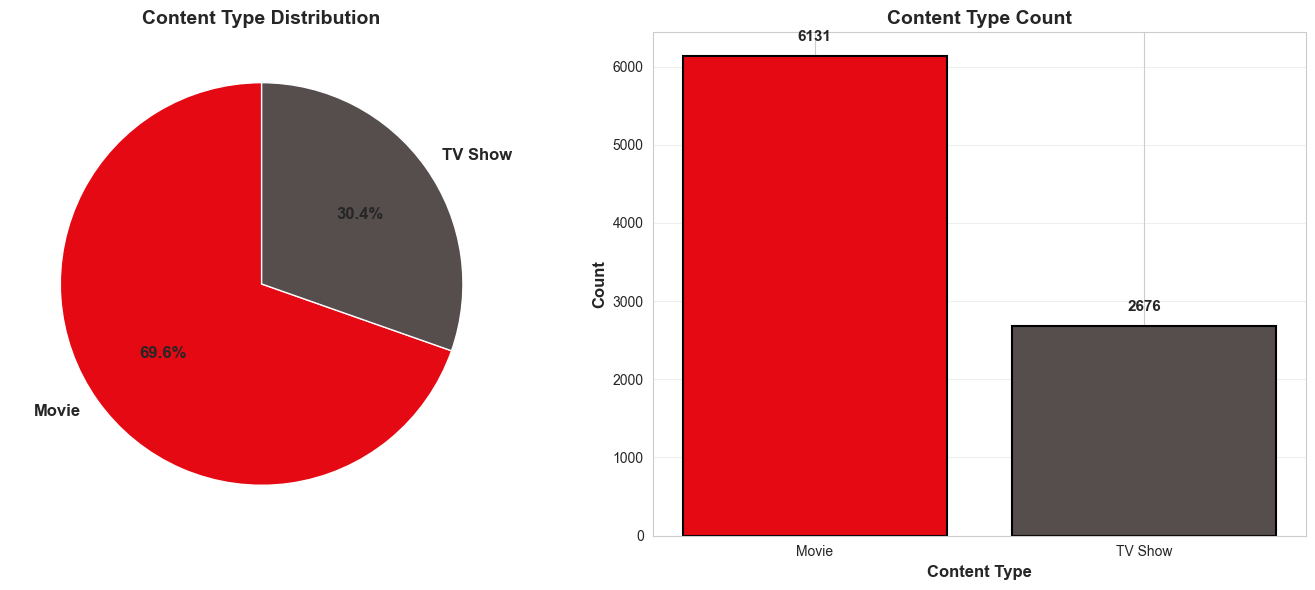

Content Type Summary:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentages:
type
Movie      69.615079
TV Show    30.384921
Name: count, dtype: float64


In [43]:
# Content Type Distribution
content_type_counts = df['type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#E50914', '#564d4d']
ax1.pie(content_type_counts.values, labels=content_type_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=colors, 
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Content Type Distribution', fontsize=14, fontweight='bold')

# Bar chart
ax2.bar(content_type_counts.index, content_type_counts.values, 
        color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Content Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Content Type Count', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (idx, val) in enumerate(content_type_counts.items()):
    ax2.text(i, val + 200, str(val), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("Content Type Summary:")
print(content_type_counts)
print(f"\nPercentages:")
print(content_type_counts / len(df) * 100)

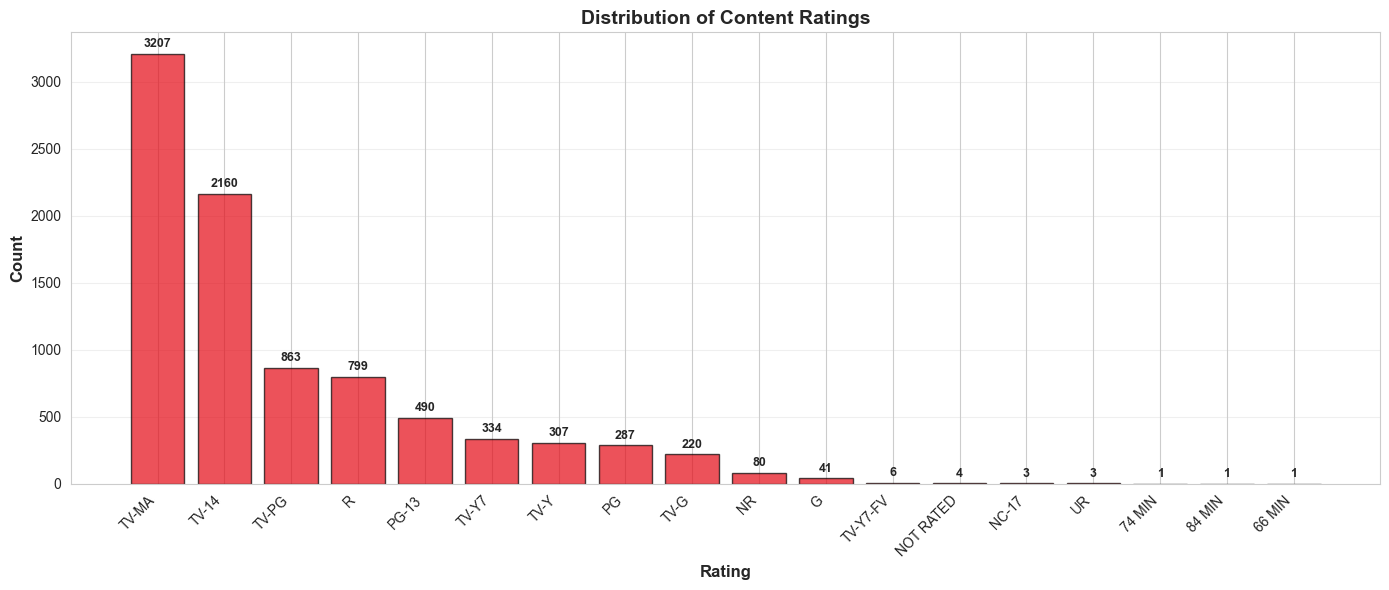

Rating Distribution:
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
NOT RATED       4
NC-17           3
UR              3
74 MIN          1
84 MIN          1
66 MIN          1
Name: count, dtype: int64

Top 5 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


In [44]:
# Ratings Distribution
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(rating_counts)), rating_counts.values, 
               color='#E50914', alpha=0.7, edgecolor='black')
plt.xticks(range(len(rating_counts)), rating_counts.index, rotation=45, ha='right')
plt.xlabel('Rating', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Content Ratings', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (idx, val) in enumerate(rating_counts.items()):
    plt.text(i, val + 50, str(val), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("Rating Distribution:")
print(rating_counts)
print(f"\nTop 5 Ratings:")
print(rating_counts.head())

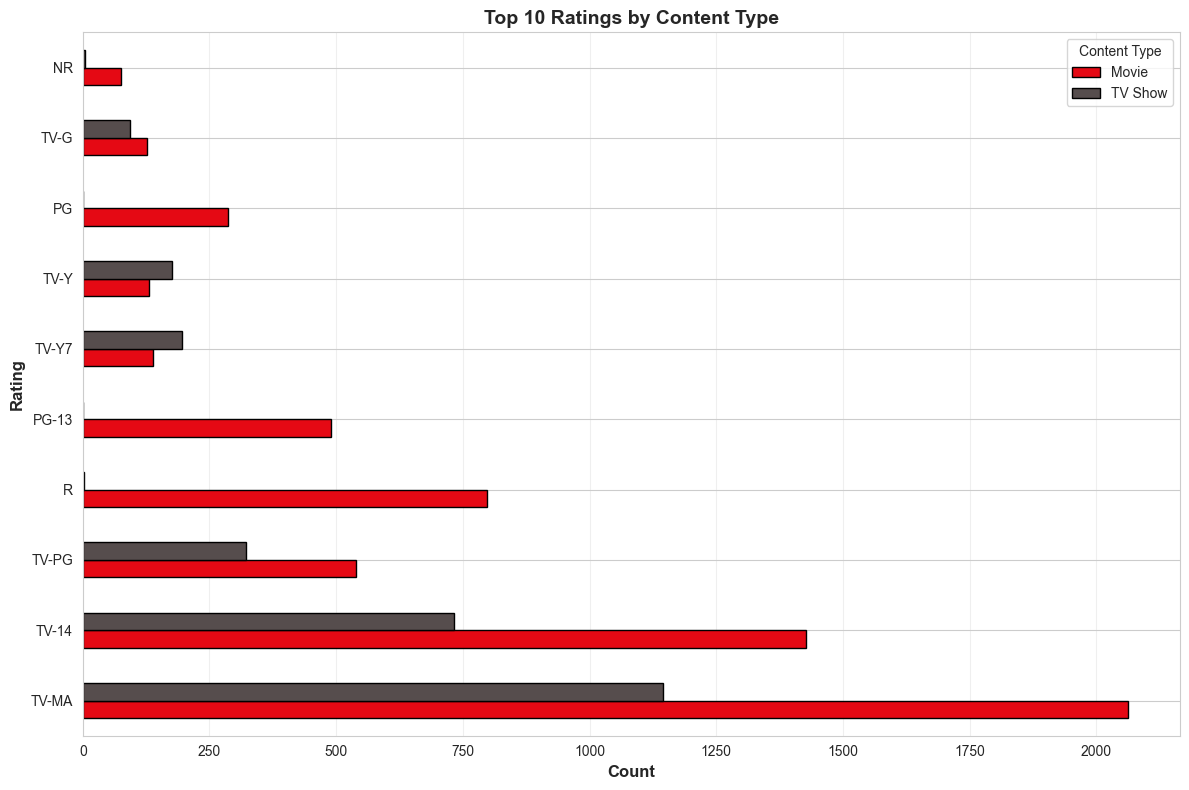

Rating by Type Crosstab (Top 10 Ratings):
type    Movie  TV Show
rating                
TV-MA    2062     1145
TV-14    1427      733
TV-PG     540      323
R         797        2
PG-13     490        0
TV-Y7     139      195
TV-Y      131      176
PG        287        0
TV-G      126       94
NR         75        5


In [45]:
# Ratings by Content Type
rating_type_crosstab = pd.crosstab(df['rating'], df['type'])

# Get top 10 ratings
top_ratings = df['rating'].value_counts().head(10).index
rating_type_subset = rating_type_crosstab.loc[top_ratings]

rating_type_subset.plot(kind='barh', figsize=(12, 8), color=['#E50914', '#564d4d'], 
                        edgecolor='black', linewidth=1)
plt.xlabel('Count', fontsize=12, fontweight='bold')
plt.ylabel('Rating', fontsize=12, fontweight='bold')
plt.title('Top 10 Ratings by Content Type', fontsize=14, fontweight='bold')
plt.legend(title='Content Type', fontsize=10)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Rating by Type Crosstab (Top 10 Ratings):")
print(rating_type_subset)

In [46]:
# Genre Distribution Analysis
import ast

# Parse genre_list column
df['genre_list_parsed'] = df['genre_list'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Flatten all genres
all_genres = []
for genres in df['genre_list_parsed']:
    all_genres.extend(genres)

# Count genre occurrences
genre_counts = pd.Series(all_genres).value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 20 Genres:")
print(genre_counts.head(20))

Total unique genres: 42

Top 20 Genres:
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


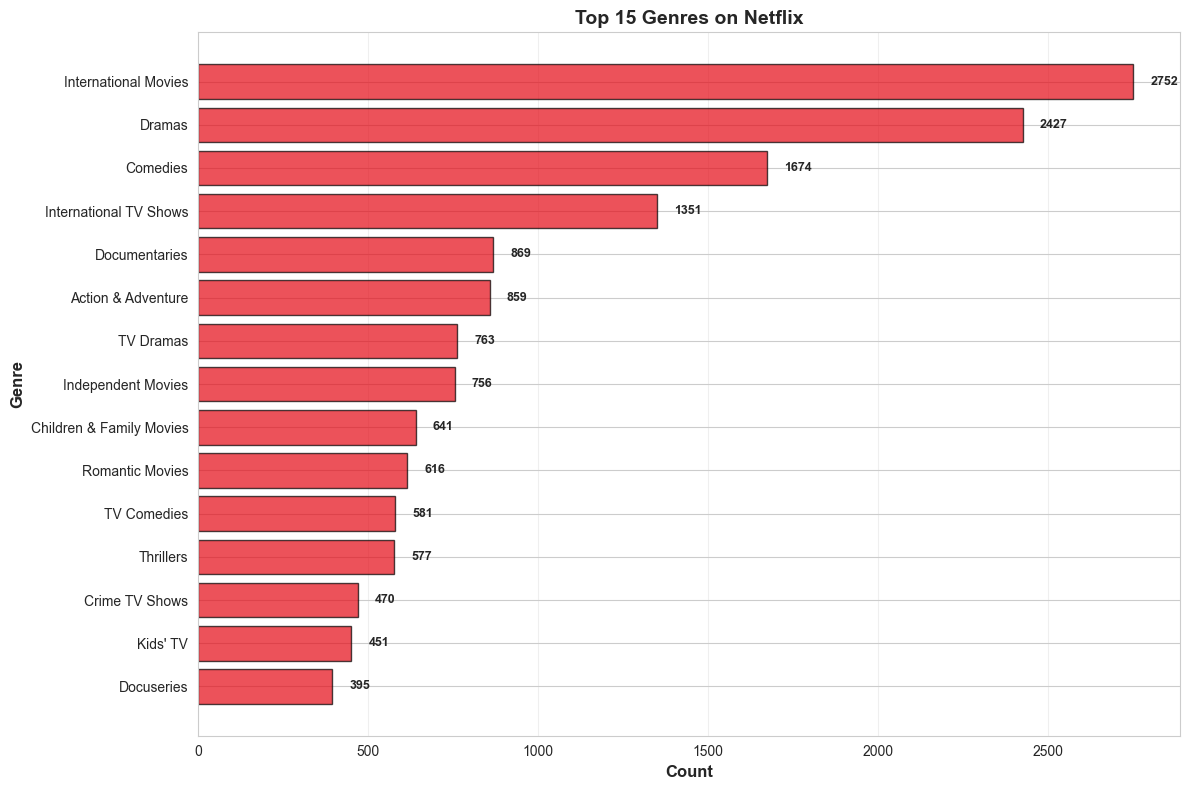

In [47]:
# Visualize Top 15 Genres
top_genres = genre_counts.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_genres)), top_genres.values, color='#E50914', 
                alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_genres)), top_genres.index, fontsize=10)
plt.xlabel('Count', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')
plt.title('Top 15 Genres on Netflix', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, val in enumerate(top_genres.values):
    plt.text(val + 50, i, str(val), va='center', fontweight='bold', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

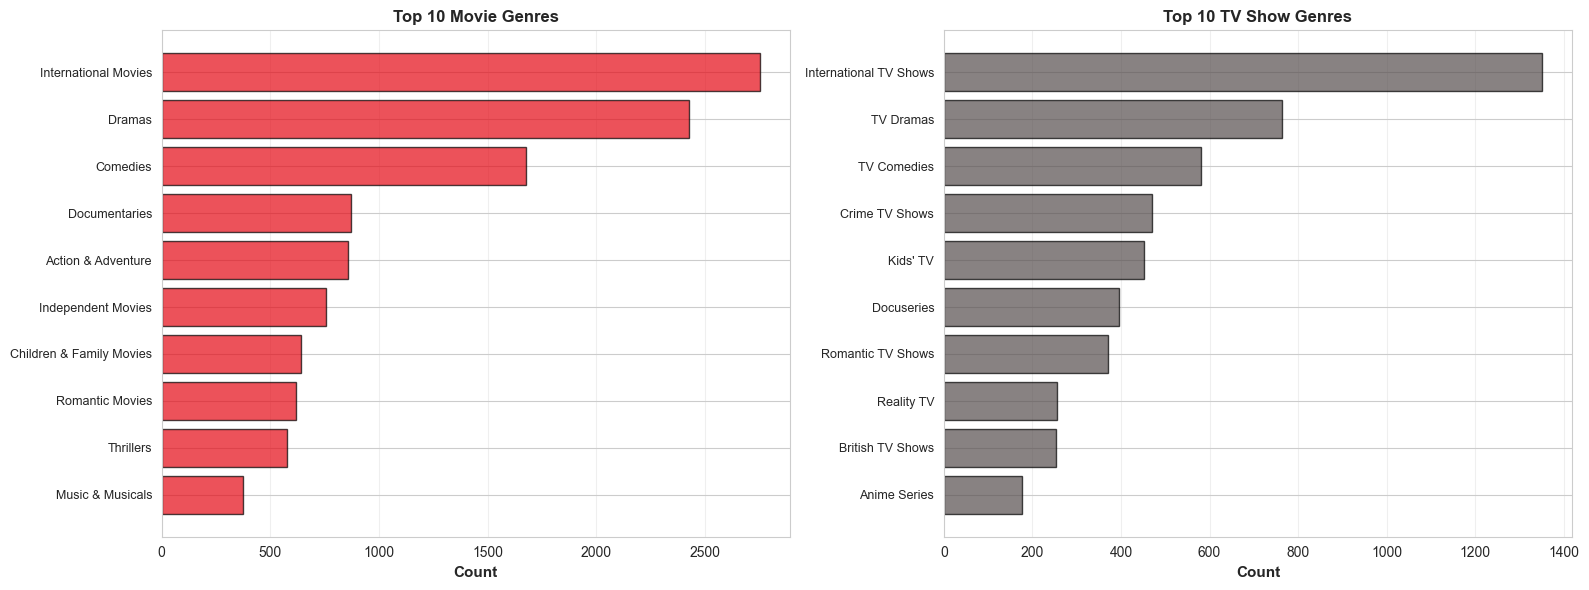

Top Movie Genres:
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

Top TV Show Genres:
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: count, dtype: int64


In [48]:
# Genre distribution by content type
movie_genres = []
tv_genres = []

for idx, row in df.iterrows():
    if row['type'] == 'Movie':
        movie_genres.extend(row['genre_list_parsed'])
    else:
        tv_genres.extend(row['genre_list_parsed'])

movie_genre_counts = pd.Series(movie_genres).value_counts().head(10)
tv_genre_counts = pd.Series(tv_genres).value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top genres for Movies
ax1.barh(range(len(movie_genre_counts)), movie_genre_counts.values, 
         color='#E50914', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(movie_genre_counts)))
ax1.set_yticklabels(movie_genre_counts.index, fontsize=9)
ax1.set_xlabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Movie Genres', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Top genres for TV Shows
ax2.barh(range(len(tv_genre_counts)), tv_genre_counts.values, 
         color='#564d4d', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(tv_genre_counts)))
ax2.set_yticklabels(tv_genre_counts.index, fontsize=9)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 TV Show Genres', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Top Movie Genres:")
print(movie_genre_counts)
print("\nTop TV Show Genres:")
print(tv_genre_counts)

## 3. Country-Level Content Contributions

In [49]:
# Parse country_list column
df['country_list_parsed'] = df['country_list'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Flatten all countries
all_countries = []
for countries in df['country_list_parsed']:
    all_countries.extend(countries)

# Count country occurrences
country_counts = pd.Series(all_countries).value_counts()

print(f"Total unique countries: {len(country_counts)}")
print(f"\nTop 20 Countries by Content Production:")
print(country_counts.head(20))

Total unique countries: 124

Top 20 Countries by Content Production:
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Name: count, dtype: int64


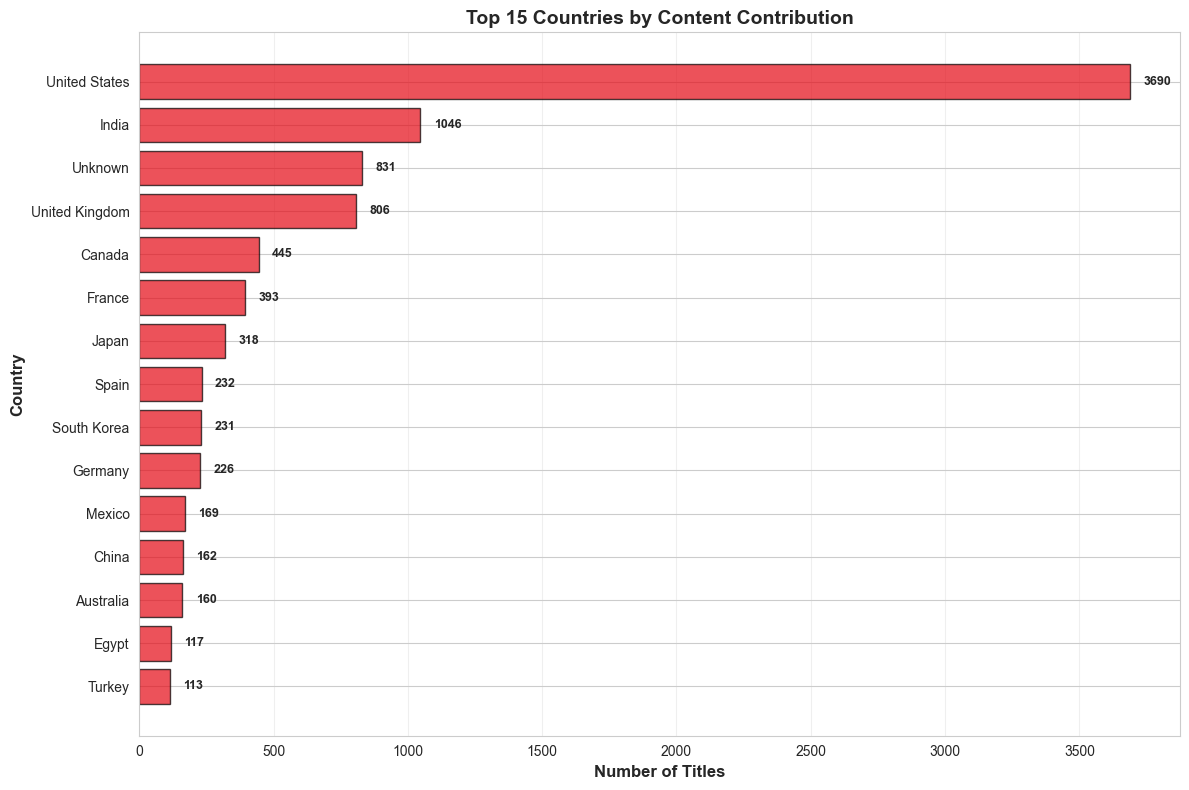

In [50]:
# Visualize Top 15 Countries
top_countries = country_counts.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_countries)), top_countries.values, 
                color='#E50914', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_countries)), top_countries.index, fontsize=10)
plt.xlabel('Number of Titles', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.title('Top 15 Countries by Content Contribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, val in enumerate(top_countries.values):
    plt.text(val + 50, i, str(val), va='center', fontweight='bold', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

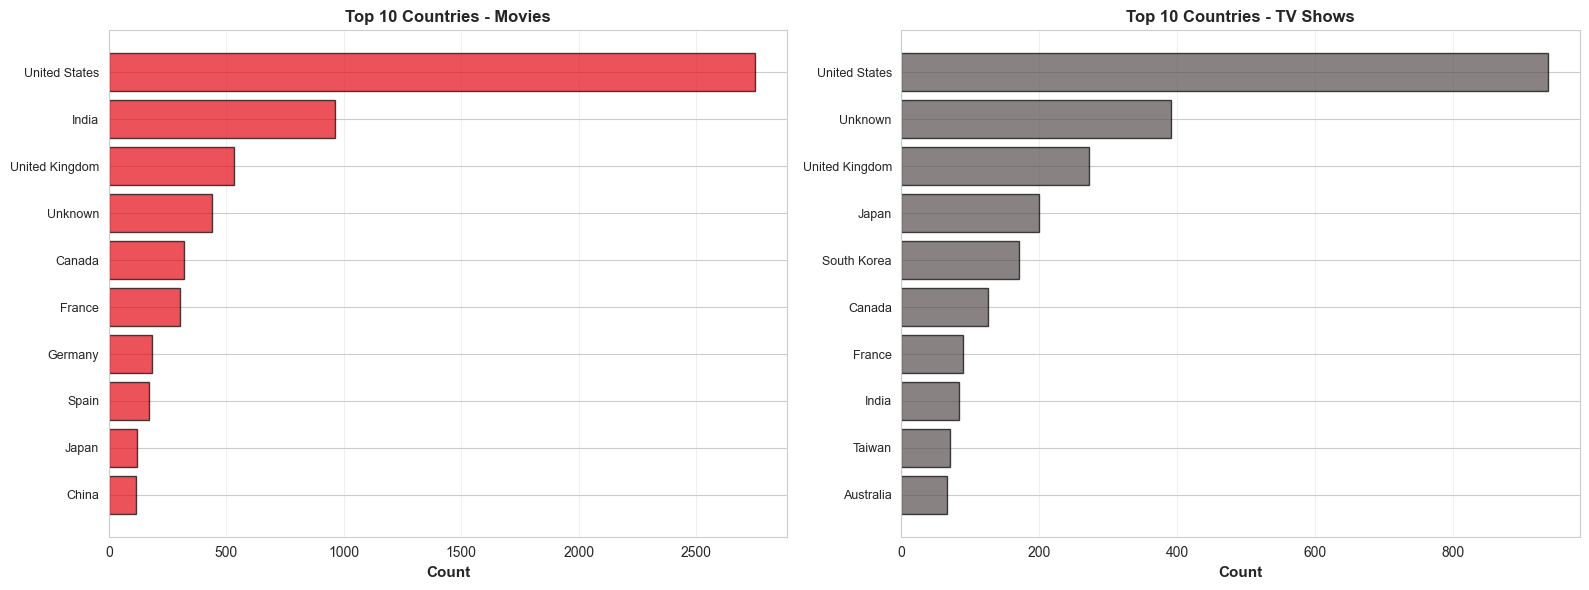

Top Countries for Movies:
United States     2752
India              962
United Kingdom     534
Unknown            440
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Name: count, dtype: int64

Top Countries for TV Shows:
United States     938
Unknown           391
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Name: count, dtype: int64


In [51]:
# Country contribution by content type
movie_countries = []
tv_countries = []

for idx, row in df.iterrows():
    if row['type'] == 'Movie':
        movie_countries.extend(row['country_list_parsed'])
    else:
        tv_countries.extend(row['country_list_parsed'])

movie_country_counts = pd.Series(movie_countries).value_counts().head(10)
tv_country_counts = pd.Series(tv_countries).value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top countries for Movies
ax1.barh(range(len(movie_country_counts)), movie_country_counts.values, 
         color='#E50914', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(movie_country_counts)))
ax1.set_yticklabels(movie_country_counts.index, fontsize=9)
ax1.set_xlabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Countries - Movies', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Top countries for TV Shows
ax2.barh(range(len(tv_country_counts)), tv_country_counts.values, 
         color='#564d4d', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(tv_country_counts)))
ax2.set_yticklabels(tv_country_counts.index, fontsize=9)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 Countries - TV Shows', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Top Countries for Movies:")
print(movie_country_counts)
print("\nTop Countries for TV Shows:")
print(tv_country_counts)

## 4. Feature Engineering

### 4.1 Content Length Category

In [52]:
# Extract duration values
def extract_duration(duration_str):
    """Extract numeric duration value"""
    if pd.isna(duration_str):
        return None
    parts = str(duration_str).split()
    if len(parts) > 0:
        try:
            return int(parts[0])
        except:
            return None
    return None

df['duration_value'] = df['duration'].apply(extract_duration)

# Check sample of duration values
print("Sample duration values:")
print(df[['type', 'duration', 'duration_value']].head(10))
print(f"\nDuration statistics by type:")
print(df.groupby('type')['duration_value'].describe())

Sample duration values:
      type   duration  duration_value
0    Movie     90 min            90.0
1  TV Show  2 Seasons             2.0
2  TV Show   1 Season             1.0
3  TV Show   1 Season             1.0
4  TV Show  2 Seasons             2.0
5  TV Show   1 Season             1.0
6    Movie     91 min            91.0
7    Movie    125 min           125.0
8  TV Show  9 Seasons             9.0
9    Movie    104 min           104.0

Duration statistics by type:
          count       mean        std  min   25%   50%    75%    max
type                                                                
Movie    6128.0  99.577187  28.290593  3.0  87.0  98.0  114.0  312.0
TV Show  2676.0   1.764948   1.582752  1.0   1.0   1.0    2.0   17.0


In [53]:
# Create Content Length Category
def categorize_content_length(row):
    """
    Categorize content length based on type and duration
    For Movies: based on minutes
    For TV Shows: based on number of seasons
    """
    if pd.isna(row['duration_value']):
        return 'Unknown'
    
    if row['type'] == 'Movie':
        duration = row['duration_value']
        if duration < 60:
            return 'Short Film'
        elif duration < 90:
            return 'Standard'
        elif duration < 120:
            return 'Long'
        else:
            return 'Epic'
    else:  # TV Show
        seasons = row['duration_value']
        if seasons == 1:
            return 'Limited Series'
        elif seasons <= 3:
            return 'Short Series'
        elif seasons <= 6:
            return 'Medium Series'
        else:
            return 'Long Running'

df['content_length_category'] = df.apply(categorize_content_length, axis=1)

print("Content Length Category Distribution:")
print(df['content_length_category'].value_counts())
print("\nCrosstab with Content Type:")
print(pd.crosstab(df['type'], df['content_length_category']))

Content Length Category Distribution:
content_length_category
Long              3092
Limited Series    1793
Standard          1380
Epic              1198
Short Series       624
Short Film         458
Medium Series      193
Long Running        66
Unknown              3
Name: count, dtype: int64

Crosstab with Content Type:
content_length_category  Epic  Limited Series  Long  Long Running  \
type                                                                
Movie                    1198               0  3092             0   
TV Show                     0            1793     0            66   

content_length_category  Medium Series  Short Film  Short Series  Standard  \
type                                                                         
Movie                                0         458             0      1380   
TV Show                            193           0           624         0   

content_length_category  Unknown  
type                              
Movie           

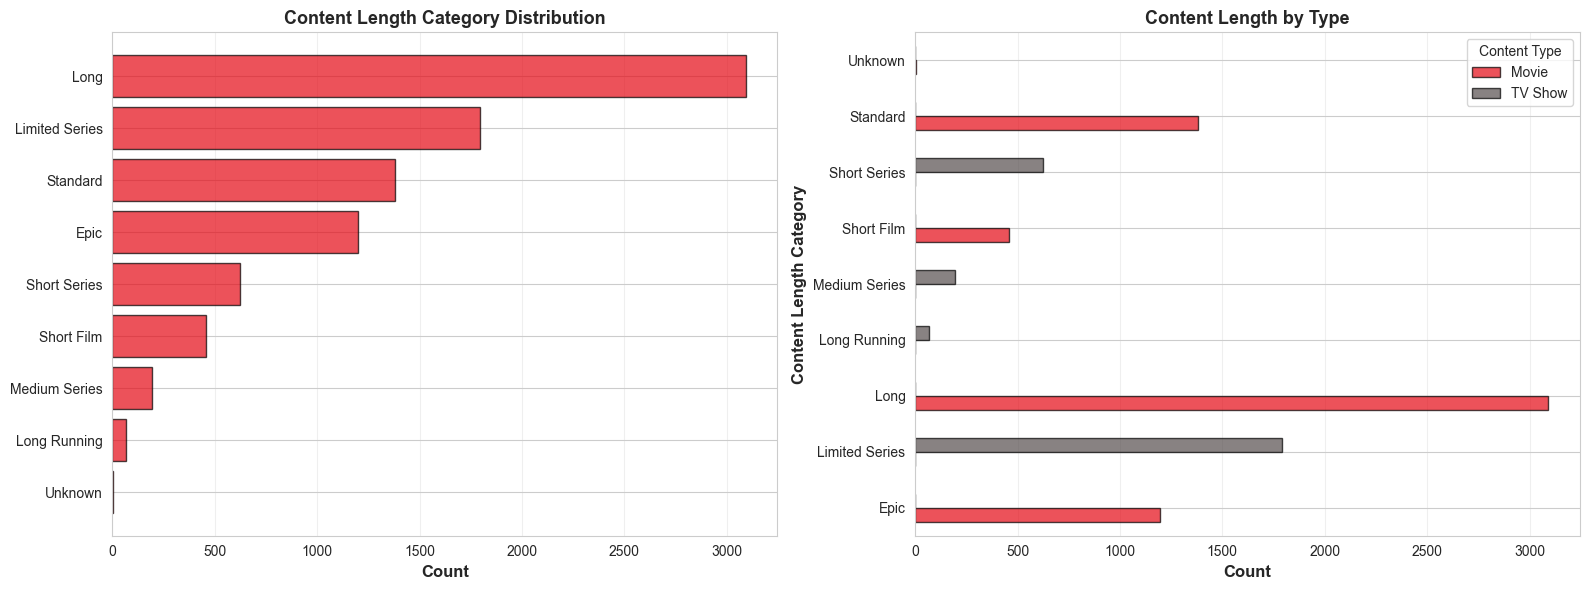

In [54]:
# Visualize Content Length Categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
length_counts = df['content_length_category'].value_counts()
axes[0].barh(range(len(length_counts)), length_counts.values, 
             color='#E50914', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(length_counts)))
axes[0].set_yticklabels(length_counts.index, fontsize=10)
axes[0].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Content Length Category Distribution', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Distribution by type
length_type_crosstab = pd.crosstab(df['content_length_category'], df['type'])
length_type_crosstab.plot(kind='barh', ax=axes[1], color=['#E50914', '#564d4d'], 
                          edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Content Length Category', fontsize=12, fontweight='bold')
axes[1].set_title('Content Length by Type', fontsize=13, fontweight='bold')
axes[1].legend(title='Content Type', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 4.2 Original vs. Licensed Content

In [55]:
# Identify Netflix Originals
# Using heuristics: title patterns, description keywords, and recent additions
def is_netflix_original(row):
    """
    Determine if content is likely a Netflix Original based on:
    1. Title containing specific patterns
    2. Description mentioning Netflix Original
    3. Listed in certain genres that indicate original production
    4. Recent release years with same year added (strong indicator)
    """
    title = str(row['title']).lower()
    description = str(row['description']).lower()
    listed_in = str(row['listed_in']).lower()
    
    # Check for explicit Netflix indicators in description
    if 'netflix' in description or 'netflix original' in description:
        return 'Original'
    
    # Check in genres/listed_in
    if 'netflix' in listed_in:
        return 'Original'
    
    # Heuristic: If content was added the same year it was released (especially recent)
    # This is a strong indicator of original content
    if pd.notna(row['year_added']) and pd.notna(row['release_year']):
        if row['release_year'] >= 2015:  # Netflix started heavy original production
            if row['year_added'] == row['release_year'] or row['year_added'] == row['release_year'] + 1:
                return 'Likely Original'
    
    return 'Licensed'

df['content_origin'] = df.apply(is_netflix_original, axis=1)

print("Content Origin Distribution:")
print(df['content_origin'].value_counts())
print(f"\nPercentages:")
print(df['content_origin'].value_counts(normalize=True) * 100)

Content Origin Distribution:
content_origin
Likely Original    4730
Licensed           4068
Original              9
Name: count, dtype: int64

Percentages:
content_origin
Likely Original    53.707278
Licensed           46.190530
Original            0.102191
Name: proportion, dtype: float64


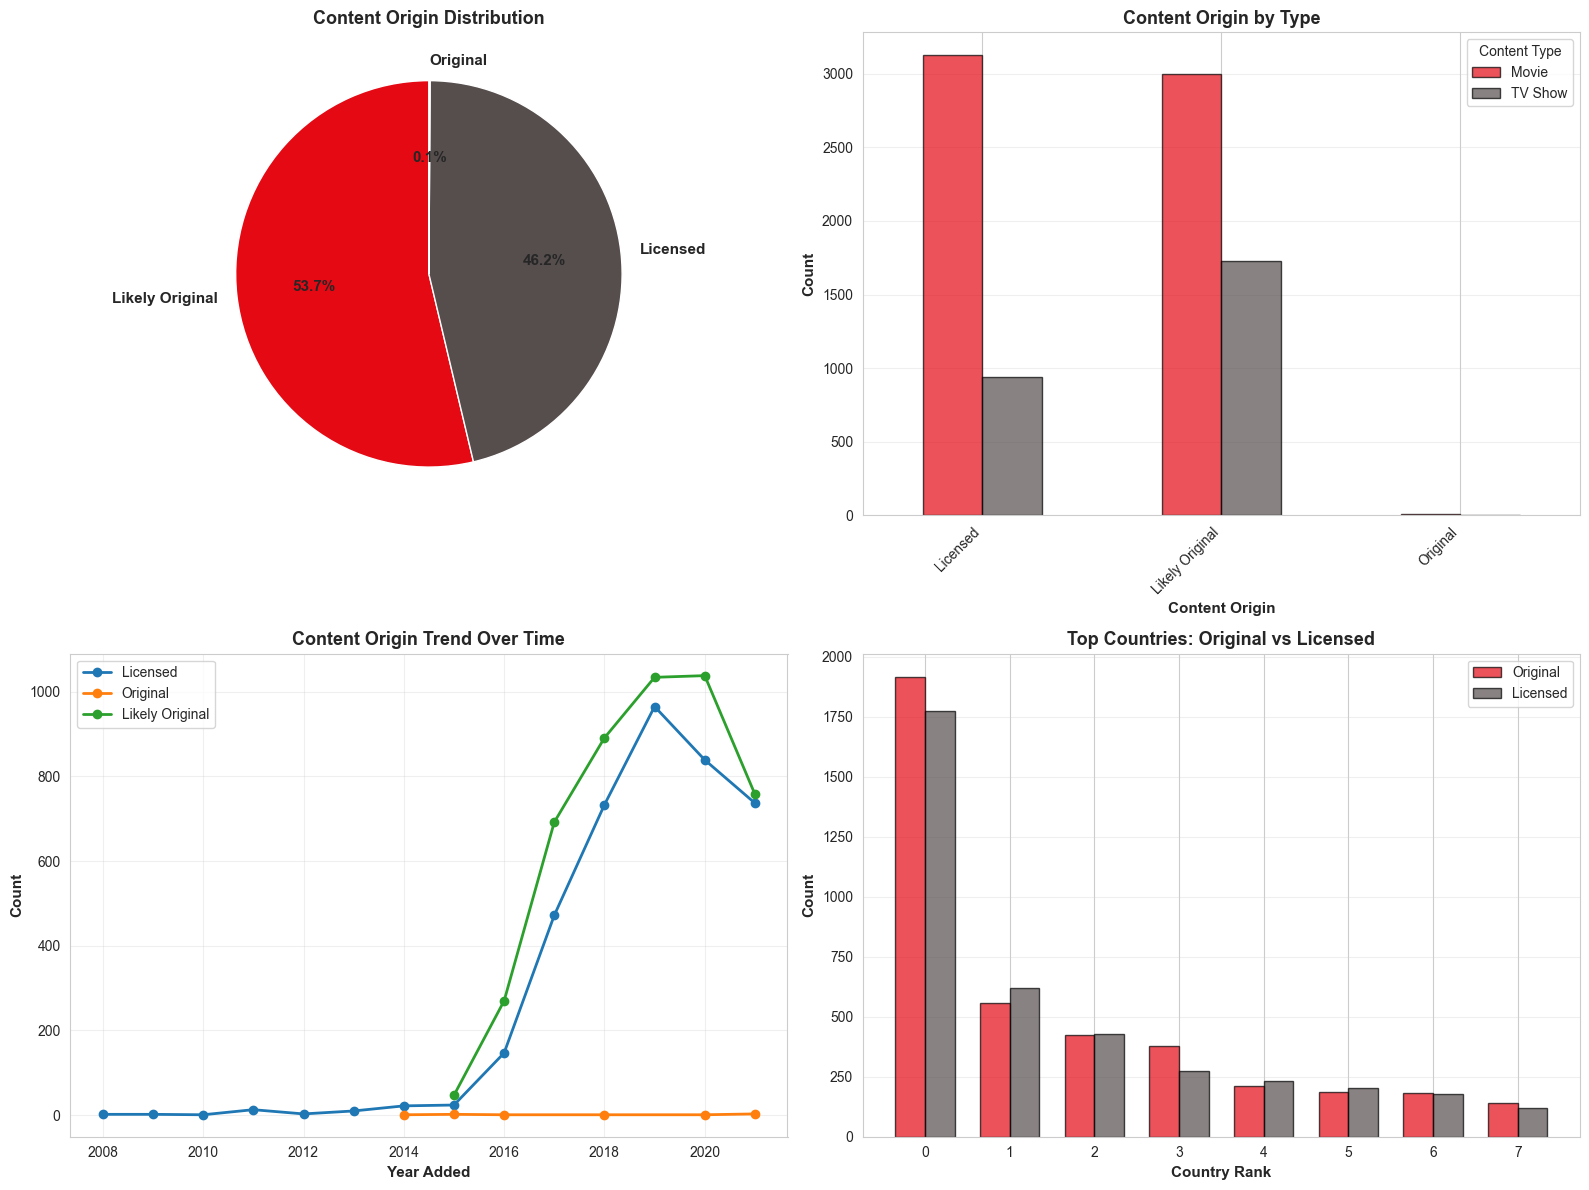


Top Countries for Original Content:
United States     1917
Unknown            559
India              425
United Kingdom     376
Canada             211
France             188
Spain              182
Japan              141
Name: count, dtype: int64

Top Countries for Licensed Content:
United States     1773
India              621
United Kingdom     430
Unknown            272
Canada             234
France             205
Japan              177
Germany            120
Name: count, dtype: int64


In [56]:
# Visualize Original vs Licensed content
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall pie chart
origin_counts = df['content_origin'].value_counts()
colors = ['#E50914', '#564d4d', '#B81D24']
axes[0, 0].pie(origin_counts.values, labels=origin_counts.index, autopct='%1.1f%%',
               colors=colors[:len(origin_counts)], startangle=90,
               textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0, 0].set_title('Content Origin Distribution', fontsize=13, fontweight='bold')

# By content type
origin_type_crosstab = pd.crosstab(df['content_origin'], df['type'])
origin_type_crosstab.plot(kind='bar', ax=axes[0, 1], color=['#E50914', '#564d4d'],
                          edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Content Origin', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Content Origin by Type', fontsize=13, fontweight='bold')
axes[0, 1].legend(title='Content Type', fontsize=10)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Content origin over time
origin_year = df.groupby(['year_added', 'content_origin']).size().reset_index(name='count')
origin_year = origin_year.dropna()

for origin in origin_year['content_origin'].unique():
    data = origin_year[origin_year['content_origin'] == origin]
    axes[1, 0].plot(data['year_added'], data['count'], marker='o', 
                    linewidth=2, label=origin)

axes[1, 0].set_xlabel('Year Added', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Content Origin Trend Over Time', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Top countries for Original vs Licensed
original_countries = []
licensed_countries = []

for idx, row in df.iterrows():
    if row['content_origin'] in ['Original', 'Likely Original']:
        original_countries.extend(row['country_list_parsed'])
    elif row['content_origin'] == 'Licensed':
        licensed_countries.extend(row['country_list_parsed'])

original_country_counts = pd.Series(original_countries).value_counts().head(8)
licensed_country_counts = pd.Series(licensed_countries).value_counts().head(8)

x = np.arange(max(len(original_country_counts), len(licensed_country_counts)))
width = 0.35

# Ensure both have same length for plotting
max_len = max(len(original_country_counts), len(licensed_country_counts))
orig_vals = list(original_country_counts.values) + [0] * (max_len - len(original_country_counts))
lic_vals = list(licensed_country_counts.values) + [0] * (max_len - len(licensed_country_counts))

bars1 = axes[1, 1].bar(x - width/2, orig_vals[:len(x)], width, 
                        label='Original', color='#E50914', alpha=0.7, edgecolor='black')
bars2 = axes[1, 1].bar(x + width/2, lic_vals[:len(x)], width,
                        label='Licensed', color='#564d4d', alpha=0.7, edgecolor='black')

axes[1, 1].set_xlabel('Country Rank', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Top Countries: Original vs Licensed', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nTop Countries for Original Content:")
print(original_country_counts)
print("\nTop Countries for Licensed Content:")
print(licensed_country_counts)

## 5. Summary and Export Enhanced Dataset

In [57]:
# Summary of new features created
print("="*80)
print("MILESTONE 2 SUMMARY - EDA & FEATURE ENGINEERING")
print("="*80)

print("\n1. EXPLORATORY DATA ANALYSIS COMPLETED:")
print("   ✓ Content growth over time analyzed")
print("   ✓ Distribution of genres, ratings, and content types visualized")
print("   ✓ Country-level content contributions identified")

print("\n2. NEW FEATURES CREATED:")
print("   ✓ year_added: Year content was added to Netflix")
print("   ✓ month_added: Month content was added to Netflix")
print("   ✓ duration_value: Numeric duration (minutes for movies, seasons for TV)")
print("   ✓ content_length_category: Categorized content length")
print("   ✓ content_origin: Original vs Licensed classification")

print("\n3. FEATURE STATISTICS:")
print(f"\nContent Length Categories:")
print(df['content_length_category'].value_counts())

print(f"\nContent Origin:")
print(df['content_origin'].value_counts())

print("\n4. DATASET DIMENSIONS:")
print(f"   Total Records: {len(df)}")
print(f"   Total Features: {len(df.columns)}")
print(f"   New Features Added: 5")

print("\n5. COLUMN NAMES IN ENHANCED DATASET:")
print(df.columns.tolist())

MILESTONE 2 SUMMARY - EDA & FEATURE ENGINEERING

1. EXPLORATORY DATA ANALYSIS COMPLETED:
   ✓ Content growth over time analyzed
   ✓ Distribution of genres, ratings, and content types visualized
   ✓ Country-level content contributions identified

2. NEW FEATURES CREATED:
   ✓ year_added: Year content was added to Netflix
   ✓ month_added: Month content was added to Netflix
   ✓ duration_value: Numeric duration (minutes for movies, seasons for TV)
   ✓ content_length_category: Categorized content length
   ✓ content_origin: Original vs Licensed classification

3. FEATURE STATISTICS:

Content Length Categories:
content_length_category
Long              3092
Limited Series    1793
Standard          1380
Epic              1198
Short Series       624
Short Film         458
Medium Series      193
Long Running        66
Unknown              3
Name: count, dtype: int64

Content Origin:
content_origin
Likely Original    4730
Licensed           4068
Original              9
Name: count, dtype: i

In [58]:
# Save the enhanced dataset
output_file = 'netflix_titles_enhanced.csv'
df.to_csv(output_file, index=False)

print(f"Enhanced dataset saved to: {output_file}")
print(f"\nSample of enhanced data:")
print(df[['title', 'type', 'release_year', 'year_added', 
         'content_length_category', 'content_origin']].head(10))

Enhanced dataset saved to: netflix_titles_enhanced.csv

Sample of enhanced data:
                              title     type  release_year  year_added  \
0              Dick Johnson Is Dead    Movie          2020      2021.0   
1                     Blood & Water  TV Show          2021      2021.0   
2                         Ganglands  TV Show          2021      2021.0   
3             Jailbirds New Orleans  TV Show          2021      2021.0   
4                      Kota Factory  TV Show          2021      2021.0   
5                     Midnight Mass  TV Show          2021      2021.0   
6  My Little Pony: A New Generation    Movie          2021      2021.0   
7                           Sankofa    Movie          1993      2021.0   
8     The Great British Baking Show  TV Show          2021      2021.0   
9                      The Starling    Movie          2021      2021.0   

  content_length_category   content_origin  
0                    Long  Likely Original  
1            S

## 6. Key Insights

### Content Growth
- Netflix content additions have shown significant growth over the years
- Recent years show increased focus on TV Shows vs Movies

### Content Distribution
- The platform has a diverse mix of Movies and TV Shows
- TV-MA and TV-14 are the most common ratings
- International content (particularly from US, India, UK) dominates

### Genre Analysis
- Documentaries, International content, and Dramas are top genres
- Genre preferences differ between Movies and TV Shows

### Content Features
- **Content Length**: Categorized into Short/Standard/Long for movies and series length for TV
- **Content Origin**: Heuristic-based classification of Original vs Licensed content
- Netflix's original content production has increased in recent years

## 7. Univariate Analysis

Let's perform detailed univariate analysis on individual variables to understand their distributions and characteristics.


3. Release Year Distribution:
Min Release Year: 1925
Max Release Year: 2021
Mean Release Year: 2014.18
Median Release Year: 2017.0
Standard Deviation: 8.82


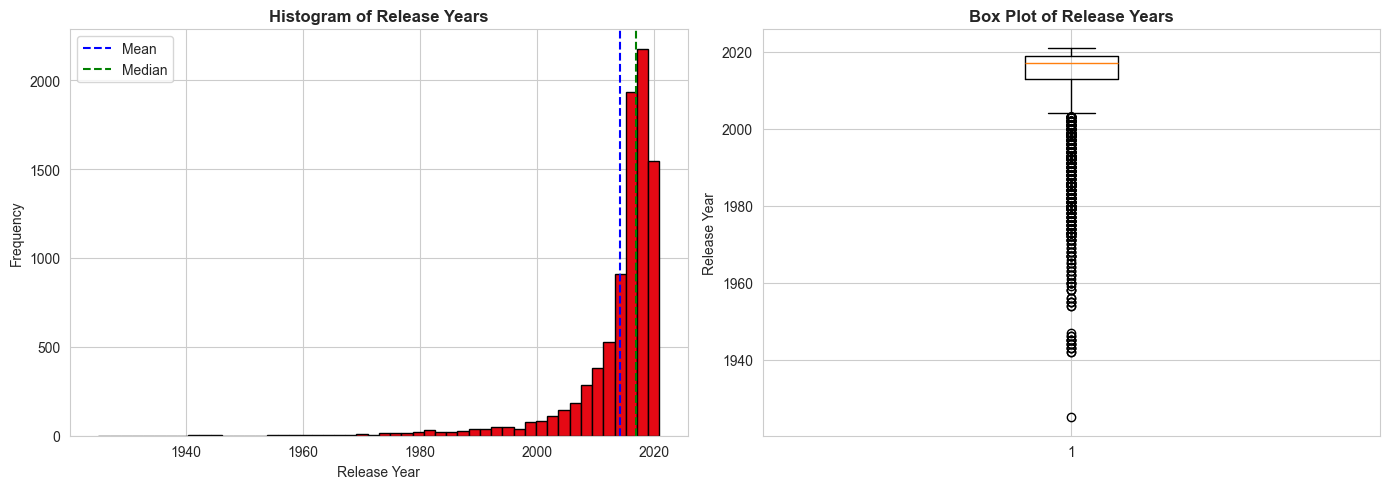

In [59]:
# 3. Release Year Distribution
print("\n" + "="*50)
print("3. Release Year Distribution:")
print(f"Min Release Year: {df['release_year'].min()}")
print(f"Max Release Year: {df['release_year'].max()}")
print(f"Mean Release Year: {df['release_year'].mean():.2f}")
print(f"Median Release Year: {df['release_year'].median()}")
print(f"Standard Deviation: {df['release_year'].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['release_year'], bins=50, color='#E50914', edgecolor='black')
axes[0].set_title('Histogram of Release Years', fontweight='bold')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['release_year'].mean(), color='blue', linestyle='--', label='Mean')
axes[0].axvline(df['release_year'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Box plot
axes[1].boxplot(df['release_year'], vert=True)
axes[1].set_title('Box Plot of Release Years', fontweight='bold')
axes[1].set_ylabel('Release Year')

plt.tight_layout()
plt.show()


4. Year Added Distribution:
Min Year Added: 2008.0
Max Year Added: 2021.0
Mean Year Added: 2018.89
Missing Values: 98


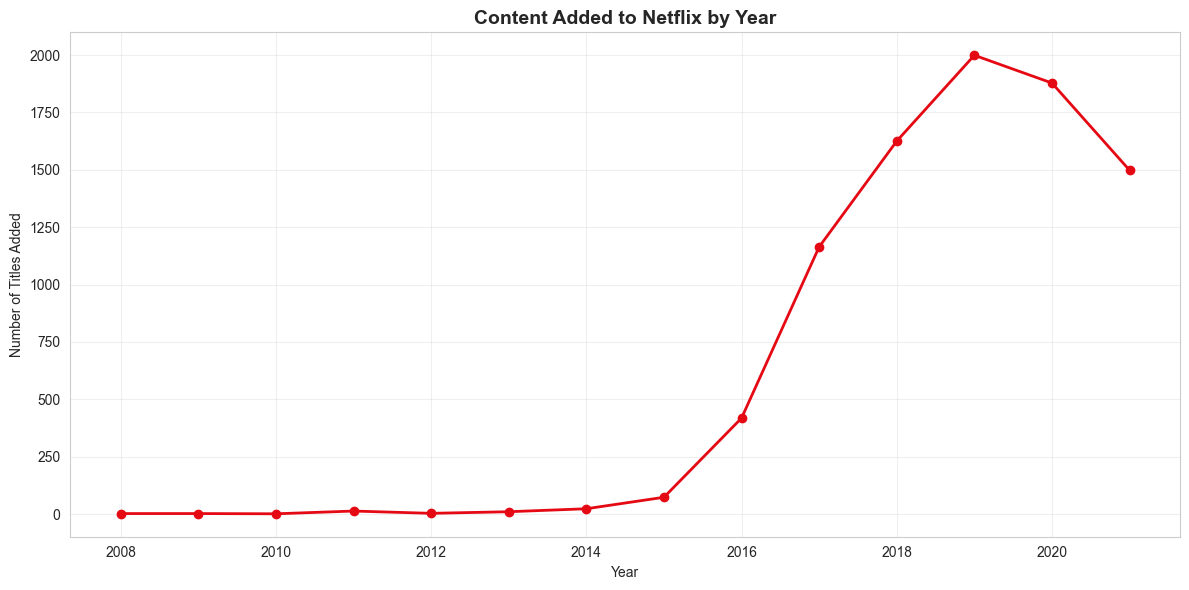

In [60]:
# 4. Year Added Distribution
print("\n" + "="*50)
print("4. Year Added Distribution:")
year_added_clean = df['year_added'].dropna()
print(f"Min Year Added: {year_added_clean.min()}")
print(f"Max Year Added: {year_added_clean.max()}")
print(f"Mean Year Added: {year_added_clean.mean():.2f}")
print(f"Missing Values: {df['year_added'].isna().sum()}")

plt.figure(figsize=(12, 6))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914', linewidth=2)
plt.title('Content Added to Netflix by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis

Let's explore relationships between pairs of variables to uncover patterns and correlations.


2. Content Type vs Release Year (Recent Trends):
type          Movie  TV Show
release_year                
2012            173       64
2013            225       63
2014            264       88
2015            398      162
2016            658      244
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315


<Figure size 1400x600 with 0 Axes>

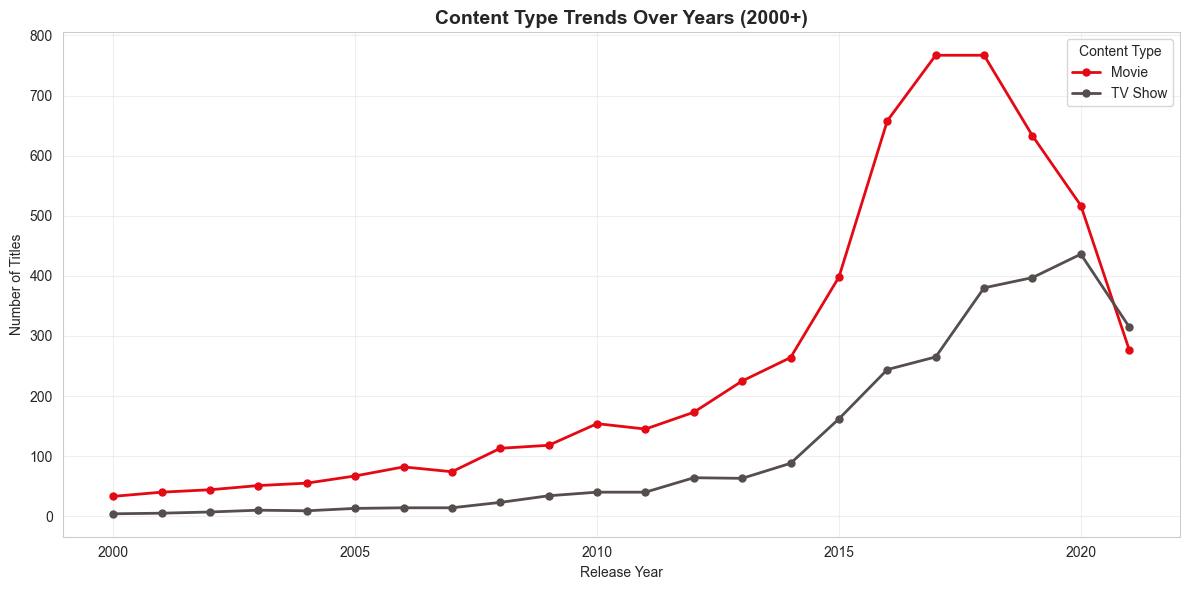

In [61]:
# 2. Content Type vs Release Year Trends
print("\n" + "="*50)
print("2. Content Type vs Release Year (Recent Trends):")

# Filter for content released after 2000
recent_df = df[df['release_year'] >= 2000]
type_year_trend = recent_df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
print(type_year_trend.tail(10))

plt.figure(figsize=(14, 6))
type_year_trend.plot(kind='line', marker='o', linewidth=2, markersize=5, color=['#E50914', '#564d4d'])
plt.title('Content Type Trends Over Years (2000+)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3. Content Type vs Year Added:
type        Movie  TV Show
year_added                
2012.0          3        0
2013.0          6        4
2014.0         19        4
2015.0         56       17
2016.0        253      165
2017.0        839      325
2018.0       1237      388
2019.0       1424      575
2020.0       1284      594
2021.0        993      505


<Figure size 1400x600 with 0 Axes>

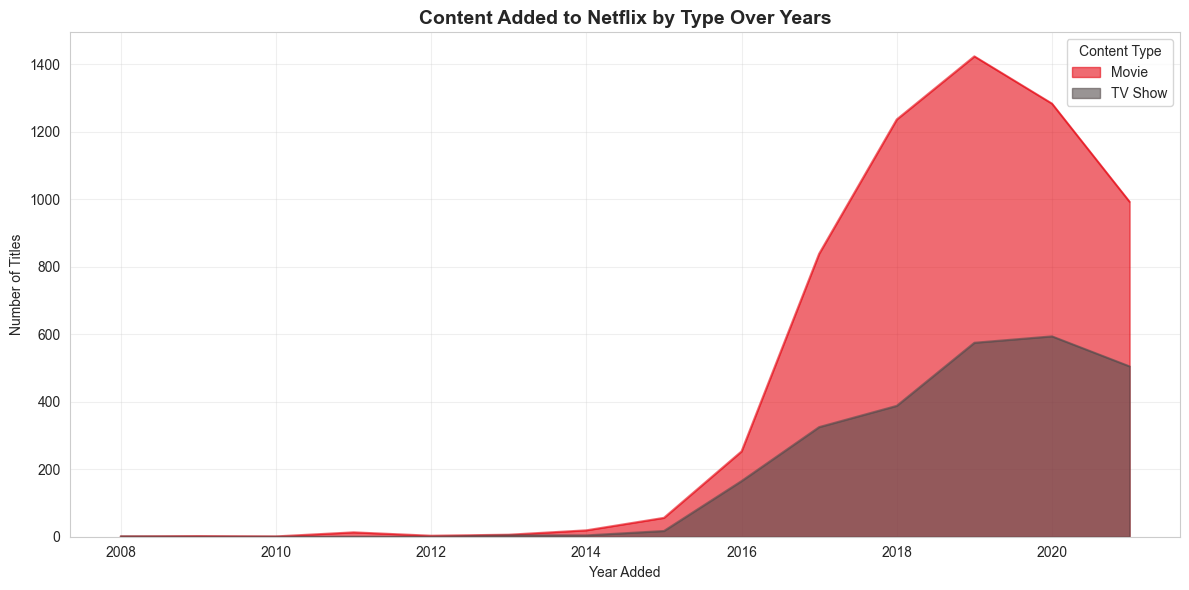

In [62]:
# 3. Content Type vs Year Added
print("\n" + "="*50)
print("3. Content Type vs Year Added:")

type_year_added = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(type_year_added.tail(10))

plt.figure(figsize=(14, 6))
type_year_added.plot(kind='area', stacked=False, alpha=0.6, color=['#E50914', '#564d4d'])
plt.title('Content Added to Netflix by Type Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


4. Content Origin vs Content Type:
type             Movie  TV Show   All
content_origin                       
Licensed          3125      943  4068
Likely Original   2999     1731  4730
Original             7        2     9
All               6131     2676  8807

Percentage Distribution:
type                 Movie    TV Show
content_origin                       
Licensed         76.819076  23.180924
Likely Original  63.403805  36.596195
Original         77.777778  22.222222


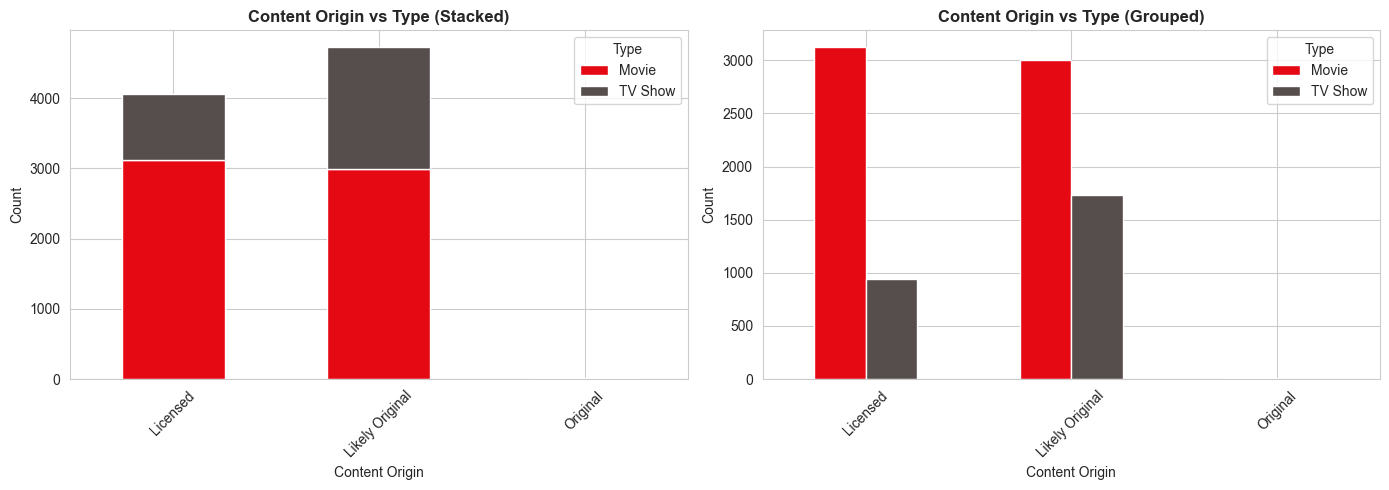

In [63]:
# 4. Content Origin vs Content Type
print("\n" + "="*50)
print("4. Content Origin vs Content Type:")

origin_type_crosstab = pd.crosstab(df['content_origin'], df['type'], margins=True)
print(origin_type_crosstab)

# Normalized version to see percentages
origin_type_pct = pd.crosstab(df['content_origin'], df['type'], normalize='index') * 100
print("\nPercentage Distribution:")
print(origin_type_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
origin_type_counts = pd.crosstab(df['content_origin'], df['type'])
origin_type_counts.plot(kind='bar', stacked=True, ax=axes[0], color=['#E50914', '#564d4d'])
axes[0].set_title('Content Origin vs Type (Stacked)', fontweight='bold')
axes[0].set_xlabel('Content Origin')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Type')

# Grouped bar chart
origin_type_counts.plot(kind='bar', ax=axes[1], color=['#E50914', '#564d4d'])
axes[1].set_title('Content Origin vs Type (Grouped)', fontweight='bold')
axes[1].set_xlabel('Content Origin')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Type')

plt.tight_layout()
plt.show()


6. Rating vs Content Type - Heatmap:


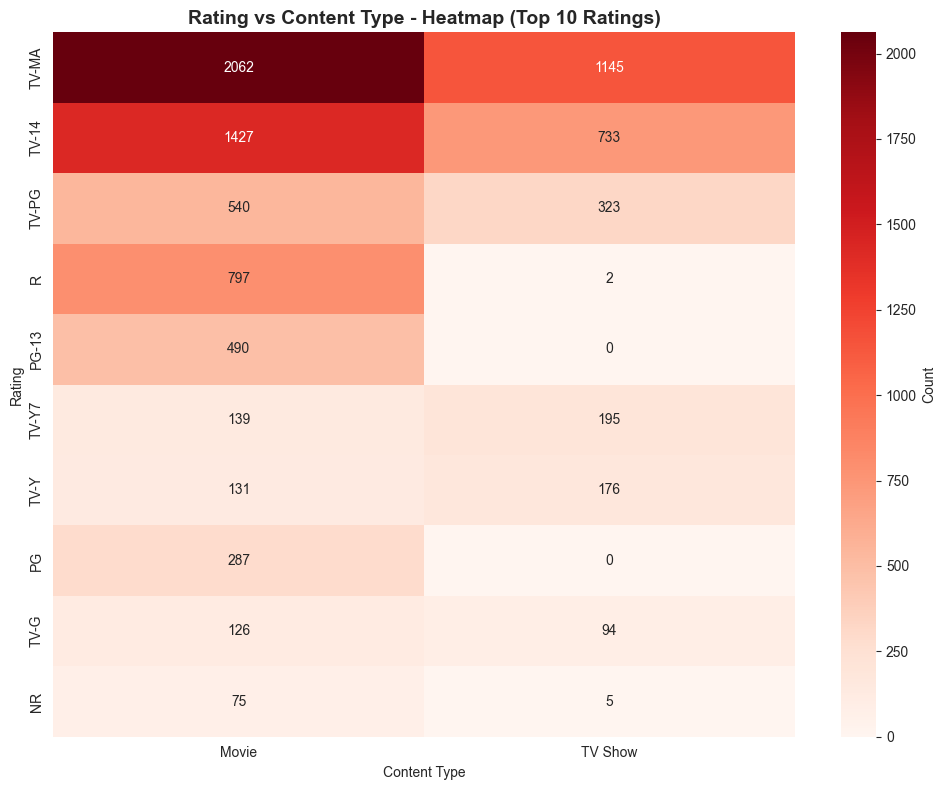

In [64]:
# 6. Rating vs Content Type - Heatmap
print("\n" + "="*50)
print("6. Rating vs Content Type - Heatmap:")

rating_type_heatmap = pd.crosstab(df['rating'], df['type'])
top_10_ratings = df['rating'].value_counts().head(10).index
rating_type_heatmap_subset = rating_type_heatmap.loc[top_10_ratings]

plt.figure(figsize=(10, 8))
sns.heatmap(rating_type_heatmap_subset, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'Count'})
plt.title('Rating vs Content Type - Heatmap (Top 10 Ratings)', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


7. Release Year vs Year Added (Time Gap Analysis):
Average time gap between release and addition: 4.69 years
Median time gap: 1.00 years
Max time gap: 93 years


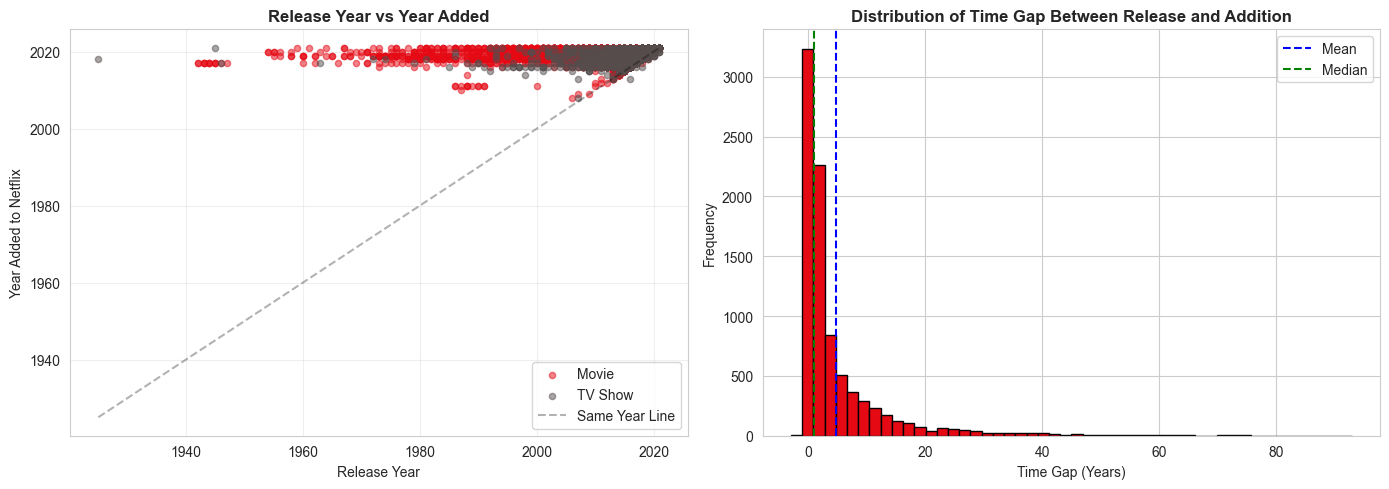

In [65]:
# 7. Release Year vs Year Added - Scatter Plot
print("\n" + "="*50)
print("7. Release Year vs Year Added (Time Gap Analysis):")

# Filter out missing values
scatter_df = df.dropna(subset=['year_added'])

# Calculate time gap
scatter_df_copy = scatter_df.copy()
scatter_df_copy['time_gap'] = scatter_df_copy['year_added'] - scatter_df_copy['release_year']
print(f"Average time gap between release and addition: {scatter_df_copy['time_gap'].mean():.2f} years")
print(f"Median time gap: {scatter_df_copy['time_gap'].median():.2f} years")
print(f"Max time gap: {scatter_df_copy['time_gap'].max():.0f} years")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
for content_type in scatter_df_copy['type'].unique():
    subset = scatter_df_copy[scatter_df_copy['type'] == content_type]
    color = '#E50914' if content_type == 'Movie' else '#564d4d'
    axes[0].scatter(subset['release_year'], subset['year_added'], alpha=0.5, s=20, 
                    label=content_type, color=color)

axes[0].plot([scatter_df_copy['release_year'].min(), scatter_df_copy['release_year'].max()],
             [scatter_df_copy['release_year'].min(), scatter_df_copy['release_year'].max()],
             'k--', alpha=0.3, label='Same Year Line')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Year Added to Netflix')
axes[0].set_title('Release Year vs Year Added', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time gap distribution
axes[1].hist(scatter_df_copy['time_gap'], bins=50, color='#E50914', edgecolor='black')
axes[1].set_xlabel('Time Gap (Years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Time Gap Between Release and Addition', fontweight='bold')
axes[1].axvline(scatter_df_copy['time_gap'].mean(), color='blue', linestyle='--', label='Mean')
axes[1].axvline(scatter_df_copy['time_gap'].median(), color='green', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Statistical Insights Summary

### Univariate Analysis Findings:
- **Release Years**: Wide distribution showing both classic and modern content, with detailed statistical measures (mean, median, standard deviation)
- **Year Added**: Exponential growth in content additions over time, particularly in recent years

### Bivariate Analysis Findings:
- **Type vs Release Year**: Movies and TV Shows show different temporal production patterns, with TV Shows gaining momentum in recent years (2000+)
- **Type vs Year Added**: Area chart visualization reveals content acquisition strategy changes over time
- **Origin vs Type**: Netflix Originals vs Licensed content distribution varies significantly by type, with increasing original production
- **Rating vs Type Heatmap**: Visual correlation matrix showing rating preferences differ between Movies and TV Shows
- **Time Gap Analysis**: Scatter plot reveals Netflix's content acquisition timeline - average gap between release and addition to platform, distinguishing fresh content from catalog additions

### Previously Covered in Sections 1-4:
- Content Type, Rating, Genre, and Country distributions
- Genre and Country breakdowns by content type
- Content length categorization and feature engineering

These analyses provide comprehensive insights into Netflix's content library structure, temporal trends, and acquisition strategies.